![](img/572_banner.png)
%%HTML

<script src="require.js"></script>


# Introduction to 1D Convolutional Neural Networks

**Mahmood Amintoosi, Spring 2026**

Computer Science Dept, Ferdowsi University of Mashhad

## Learning Objectives
By the end of this chapter, you will:
- Understand how 1D convolution works mathematically and intuitively
- Apply 1D CNNs to time series data and signal processing tasks
- Recognize the relationship between kernel size, receptive field, and smoothing effects
- Be prepared to extend these concepts to 2D convolution for images

---

## 1. Why 1D Convolution?

Before diving into image processing with 2D CNNs, let's understand convolution in one dimension. Many real-world problems involve sequential or time-series data:

| Domain | Example Data |
|--------|-------------|
| **Finance** | Stock prices, trading volumes over time |
| **Healthcare** | ECG signals, heart rate monitoring |
| **Audio** | Sound waves, speech signals |
| **IoT/Sensors** | Temperature readings, accelerometer data |
| **Natural Language** | Text sequences (though often handled differently) |
| **Traffic Forecasting** | Traffic parameters, like speed and volume |

1D CNNs are particularly effective for these data types because they can:
- **Detect local patterns** regardless of their position in the sequence
- **Reduce dimensionality** while preserving important features
- **Share parameters** across the entire sequence

---

## 2. Mathematical Foundation of 1D Convolution

### 2.1 The Convolution Operation

Given an input signal $x$ of length $n$ and a kernel (filter) $w$ of length $k$, the convolution operation produces output $y$:

$$y[i] = \sum_{j=0}^{k-1} x[i+j] \cdot w[j]$$

where $i$ ranges from $0$ to $n-k$ (for "valid" convolution).

### 2.2 Manual Example

Let's trace through a simple convolution:

```
Input x:     [1, 5, 3, 4, 8]
Kernel w:    [1/3, 1/3, 1/3]  (moving average filter)

y[0] = 1×(1/3) + 5×(1/3) + 3×(1/3) = 9/3 = 3.0
y[1] = 5×(1/3) + 3×(1/3) + 4×(1/3) = 12/3 = 4.0
y[2] = 3×(1/3) + 4×(1/3) + 8×(1/3) = 15/3 = 5.0

Output y:    [3.0, 4.0, 5.0]
```

Notice how the kernel "slides" across the input, computing a weighted sum at each position.

### 2.3 Different Kernel Effects

The same input with different kernels produces different results:

| Kernel | Effect | Output for [1, 5, 3, 4, 8] |
|--------|--------|---------------------------|
| `[1/3, 1/3, 1/3]` | Moving average (smoothing) | `[3.0, 4.0, 5.0]` |
| `[0.25, 0.5, 0.25]` | Weighted average (center-weighted) | `[3.5, 3.75, 4.75]` |
| `[-1, 0, 1]` | Edge detection (approximate derivative) | `[2, -1, 4]` |
| `[1, -2, 1]` | Second derivative (peak detection) | `[-6, 3, 6]` |

> **Exercise:** Verify the edge detection kernel output. What pattern do you notice about where the values change significantly?

---

## 3. Implementing 1D Convolution

### 3.1 Using SciPy


In [38]:
import numpy as np
from scipy import signal

# Define input and kernel
x = np.array([1, 5, 3, 4, 8])
w = np.array([1/3, 1/3, 1/3])

# Apply convolution
y = signal.convolve(x, w, mode="valid")
print(f"Input:  {x}")
print(f"Output: {y}")

Input:  [1 5 3 4 8]
Output: [3. 4. 5.]


**Mode options:**
- `"valid"`: Returns only positions where kernel fully overlaps input (size: $n-k+1$)
- `"same"`: Returns same length as input with zero-padding
- `"full"`: Returns all positions including partial overlaps (size: $n+k-1$)

### 3.2 Using PyTorch

PyTorch expects input tensors with shape **(batch_size, channels, length)**:

In [39]:
import torch
import torch.nn as nn
import numpy as np

# Reshape input: (samples, channels, length)
x = np.array([1, 5, 3, 4, 8])
x_tensor = torch.from_numpy(x).float().view(1, 1, 5)

# Define Conv1d layer
conv1d = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# Initialize with moving average weights
w = torch.tensor([1/3, 1/3, 1/3]).view(1, 1, 3)
conv1d.weight.data = w

# Apply convolution
y_tensor = conv1d(x_tensor)
print(y_tensor)
# tensor([[[3., 4., 5.]]], grad_fn=<ConvolutionBackward0>)

tensor([[[3., 4., 5.]]], grad_fn=<ConvolutionBackward0>)



**Key parameters:**
- `in_channels`: Number of input features (e.g., 1 for univariate time series)
- `out_channels`: Number of filters (output features)
- `kernel_size`: Length of the convolution window
- `stride`: Step size between positions (default: 1)
- `padding`: Zeros added to both sides (default: 0)

---

## 4. Application: Signal Denoising

One of the most intuitive applications of 1D convolution is smoothing noisy signals. Let's explore this with a sine wave.

### 4.1 Generating Noisy Data


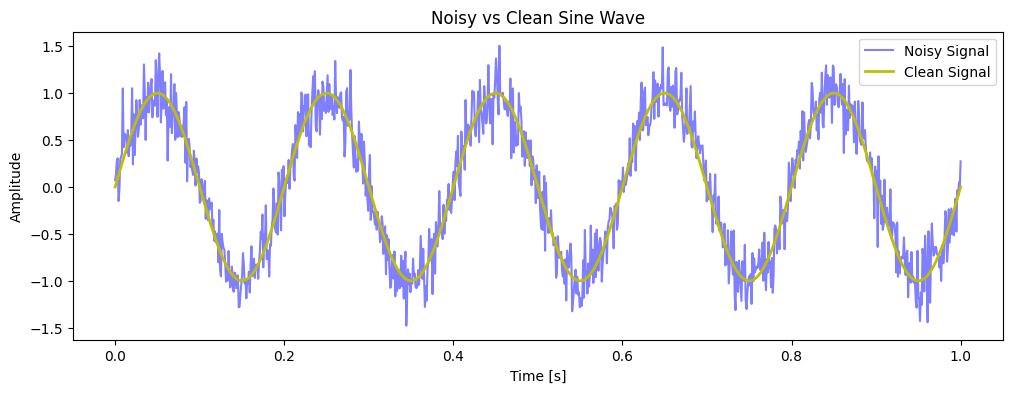

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Generate clean sine wave
t = np.linspace(0, 1, 1000)
frequency = 5
clean_signal = np.sin(2 * np.pi * frequency * t)

# Add Gaussian noise
noise = np.random.normal(0, 0.2, clean_signal.shape)
noisy_signal = clean_signal + noise

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, 'b', alpha=0.5, label='Noisy Signal')
plt.plot(t, clean_signal, 'y', linewidth=2, label='Clean Signal')
plt.legend()
plt.title('Noisy vs Clean Sine Wave')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()



### 4.2 Effect of Kernel Size

The kernel size determines the "window" of smoothing. Let's compare:

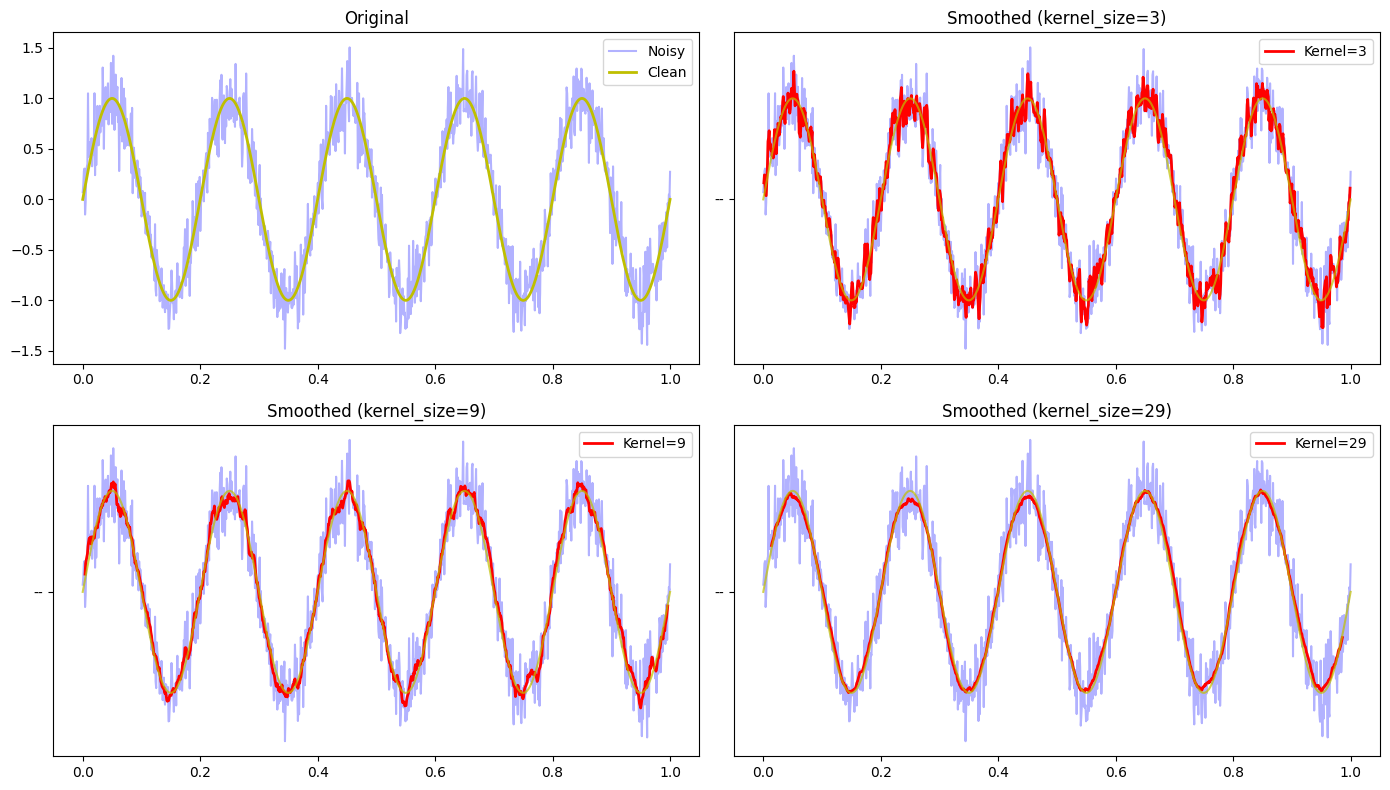

In [41]:
def smooth_signal(signal, kernel_size):
    """Apply moving average smoothing"""
    kernel = np.ones(kernel_size) / kernel_size
    conv1d = nn.Conv1d(1, 1, kernel_size, bias=False)
    conv1d.weight.data = torch.tensor(kernel).view(1, 1, kernel_size)
    
    # Prepare input
    X = signal.reshape(1, 1, -1)
    X_tensor = torch.from_numpy(X)
    
    # Apply convolution
    with torch.no_grad():
        y_tensor = conv1d(X_tensor)
    
    return y_tensor.detach().numpy().squeeze()

# Test different kernel sizes
kernel_sizes = [3, 9, 29]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t, noisy_signal, 'b', alpha=0.3, label='Noisy')
axes[0, 0].plot(t, clean_signal, 'y', linewidth=2, label='Clean')
axes[0, 0].set_title('Original')
axes[0, 0].legend()

for idx, k in enumerate(kernel_sizes):
    ax = axes[(idx+1)//2, (idx+1)%2]
    smoothed = smooth_signal(noisy_signal, k)
    
    # Adjust time axis (output is shorter due to valid convolution)
    t_out = t[k//2 : k//2 + len(smoothed)]
    
    ax.plot(t, noisy_signal, 'b', alpha=0.3)
    ax.plot(t_out, smoothed, 'r', linewidth=2, label=f'Kernel={k}')
    ax.plot(t, clean_signal, 'y', '--', alpha=0.7)
    ax.set_title(f'Smoothed (kernel_size={k})')
    ax.legend()

plt.tight_layout()
plt.show()

---

## Understanding Phase Delay in Convolution

When we apply a 1D convolution with kernel size $k$, the output at each position represents a weighted average (or sum) of $k$ input values. By default, PyTorch's `Conv1d` with `padding=0` uses **"valid"** convolution, meaning the kernel only slides where it fully overlaps with the input.

### The Phase Delay Phenomenon

The output value at index $i$ actually corresponds to information centered around index $i + \frac{k-1}{2}$ in the original signal. This creates a **phase delay** (or lag) of approximately $\frac{k}{2}$ samples.

For example, with kernel size 29:
- The output at position 0 uses input samples 0–28
- The center of this window is at position 14
- Therefore, the output appears to "lag" behind the input by ~14 samples

### Visualizing the Effect

We can demonstrate this by plotting the smoothed signal **with and without** offset correction:

- **With offset correction** (`t[k//2 : k//2 + len(smoothed)]`): We manually shift the time axis to align peaks, which is useful for comparison but hides the delay
- **Without offset correction**: The smoothed curve appears shifted to the left (earlier in time), revealing the true phase delay

---

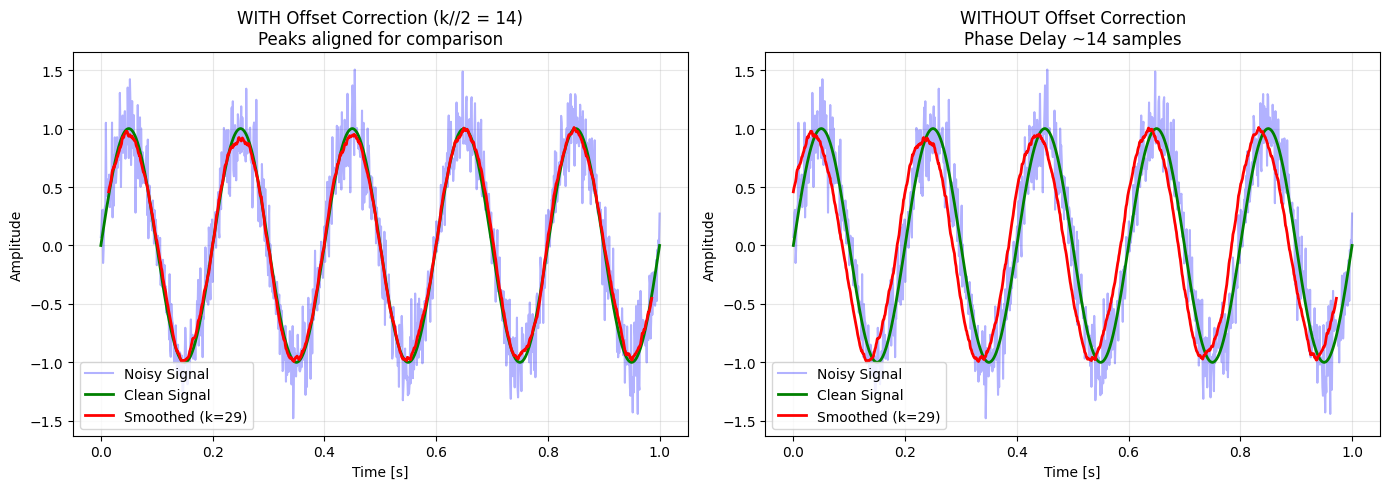

In [42]:
# Generate smoothed signal with kernel size 29
kernel_size = 29
smoothed = smooth_signal(noisy_signal, kernel_size)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PLOT: With offset correction (aligned for comparison)
ax1 = axes[0]
ax1.plot(t, noisy_signal, 'b', alpha=0.3, label='Noisy Signal')
ax1.plot(t, clean_signal, 'g', linewidth=2, label='Clean Signal')

# Shift time axis by k//2 to align peaks (hides the delay)
t_corrected = t[kernel_size//2 : kernel_size//2 + len(smoothed)]
ax1.plot(t_corrected, smoothed, "r", linewidth=2, label=f'Smoothed (k={kernel_size})')

ax1.set_title(f'WITH Offset Correction (k//2 = {kernel_size//2})\nPeaks aligned for comparison')
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Amplitude")
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Without offset correction (shows phase delay)
ax2 = axes[1]
ax2.plot(t, noisy_signal, 'b', alpha=0.3, label='Noisy Signal')
ax2.plot(t, clean_signal, 'g', linewidth=2, label='Clean Signal')

# Plot at actual output positions (no offset) - output is shorter
t_actual = t[:len(smoothed)]  # Starts from beginning, no shift
ax2.plot(t_actual, smoothed, "r", linewidth=2, label=f'Smoothed (k={kernel_size})')

ax2.set_title(f'WITHOUT Offset Correction\nPhase Delay ~{kernel_size//2} samples')
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Amplitude")
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

<!-- ### Key Takeaways

| Aspect | Without Offset | With Offset |
|--------|---------------|-------------|
| **Purpose** | Shows true convolution behavior | Enables visual comparison with original |
| **Time axis** | Starts at $t=0$, output is shorter | Shifted by $k/2$, aligned with input |
| **Phase delay** | **Visible** as leftward shift | **Hidden** by manual correction |
| **Use case** | Understanding convolution mechanics | Presentation, peak alignment analysis | 


> **Important**: The phase delay is a fundamental property of causal filtering. In real-time applications (e.g., live ECG monitoring), this delay matters! For offline analysis, we can use non-causal filtering or accept the delay for better smoothing.-->


**Observations:**
- **Small kernel (3):** Removes high-frequency noise but preserves most signal detail
- **Medium kernel (9):** Stronger smoothing, some phase shift
- **Large kernel (29):** Very smooth but may blur important features and introduces significant phase delay

### 4.3 The Trade-off: Smoothing vs Detail Preservation

| Kernel Size | Noise Reduction | Detail Preservation | Phase Shift |
|-------------|----------------|---------------------|-------------|
| Small | Low | High | Minimal |
| Medium | Medium | Medium | Moderate |
| Large | High | Low | Significant |

> **Key Insight:** The kernel size determines the **receptive field**—how much of the input each output point can "see." Larger kernels see more context but lose localization precision.


## 5. Pattern Detection with Template Matching

One of the most powerful applications of 1D convolution is **template matching**—detecting a specific pattern within a longer signal. This is the foundation of many real-world systems:

| Application | What We Detect |
|-----------|---------------|
| **Speech recognition** | Specific phonemes in audio |
| **Seismic monitoring** | Earthquake signatures in sensor data |
| **Fault detection** | Anomaly patterns in machine vibrations |
| **Music information retrieval** | Drum beats or melody fragments |

### 5.1 The Concept: Convolution as Pattern Matching

When we convolve a signal with a template (kernel), the output peaks **where the signal matches the template**. This works because:

$$\text{Output}[i] = \sum_{j} \text{Signal}[i+j] \times \text{Template}[j]$$

High values indicate strong similarity; low (or negative) values indicate mismatch.

### 5.2 Example: Detecting a "Triangle" Pattern in Noise

Let's create a simple, visual example: detecting a triangular pulse in a noisy signal.

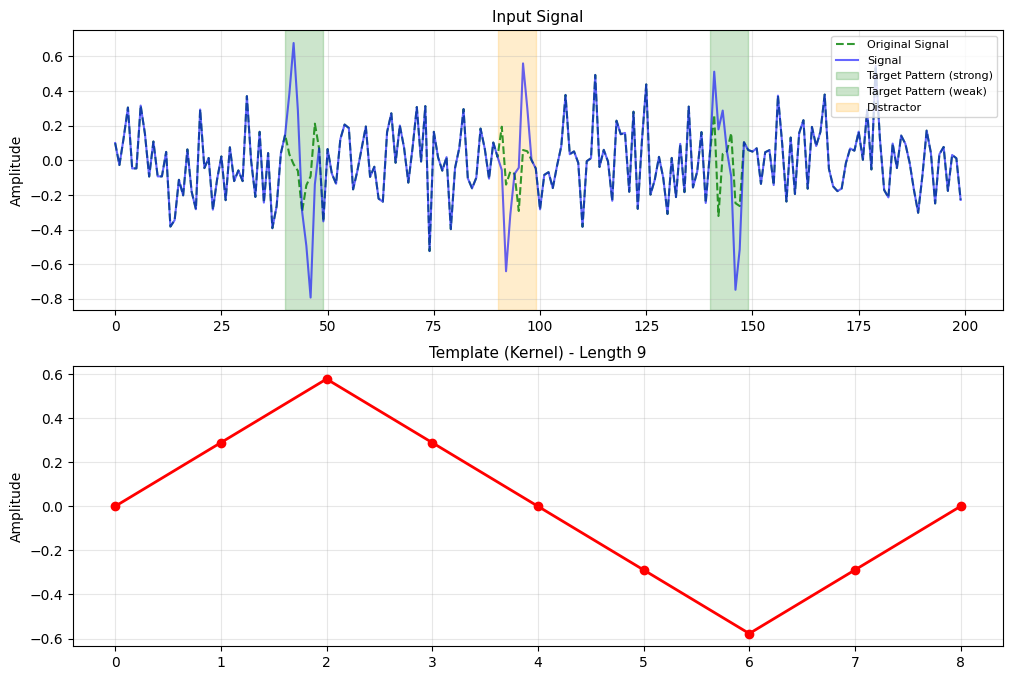

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.signal import find_peaks

# Set seed for reproducibility
np.random.seed(42)

# Create the TEMPLATE pattern we want to detect
template = np.array([0, 0.5, 1.0, 0.5, 0, -0.5, -1.0, -0.5, 0])
template_length = len(template)

# Create a long signal with the pattern appearing at specific locations
signal_length = 200
signal = np.random.normal(0, 0.2, signal_length)
orig_signal = signal.copy()

# Insert the pattern at positions 40 and 140 (with different amplitudes)
signal[40:40+template_length] += template * 0.7    # Strong amplitude
signal[140:140+template_length] += template * 0.5  # Weaker amplitude

# Add a distractor that is the flipped of the above template
distractor = np.flip(template)
signal[90:90+len(distractor)] += distractor  * 0.5

t = np.arange(signal_length)

# Normalize template for convolution
template_normalized = template - np.mean(template)
template_normalized = template_normalized / np.linalg.norm(template_normalized)

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Original signal with highlighted regions
axes[0].plot(t, orig_signal, 'g--', alpha=0.8, label='Original Signal')
axes[0].plot(t, signal, 'b-', alpha=0.6, label='Signal')
axes[0].axvspan(40, 40+template_length, alpha=0.2, color='green', label='Target Pattern (strong)')
axes[0].axvspan(140, 140+template_length, alpha=0.2, color='green', label='Target Pattern (weak)')
axes[0].axvspan(90, 90+len(distractor), alpha=0.2, color='orange', label='Distractor')
axes[0].set_title('Input Signal', fontsize=11)
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Template
axes[1].plot(template_normalized, 'r-o', linewidth=2, markersize=6)
axes[1].set_title(f'Template (Kernel) - Length {template_length}', fontsize=11)
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)


### 5.3 Applying Template Matching with Convolution

Now we use the template as our convolution kernel. The output will peak where the pattern matches:


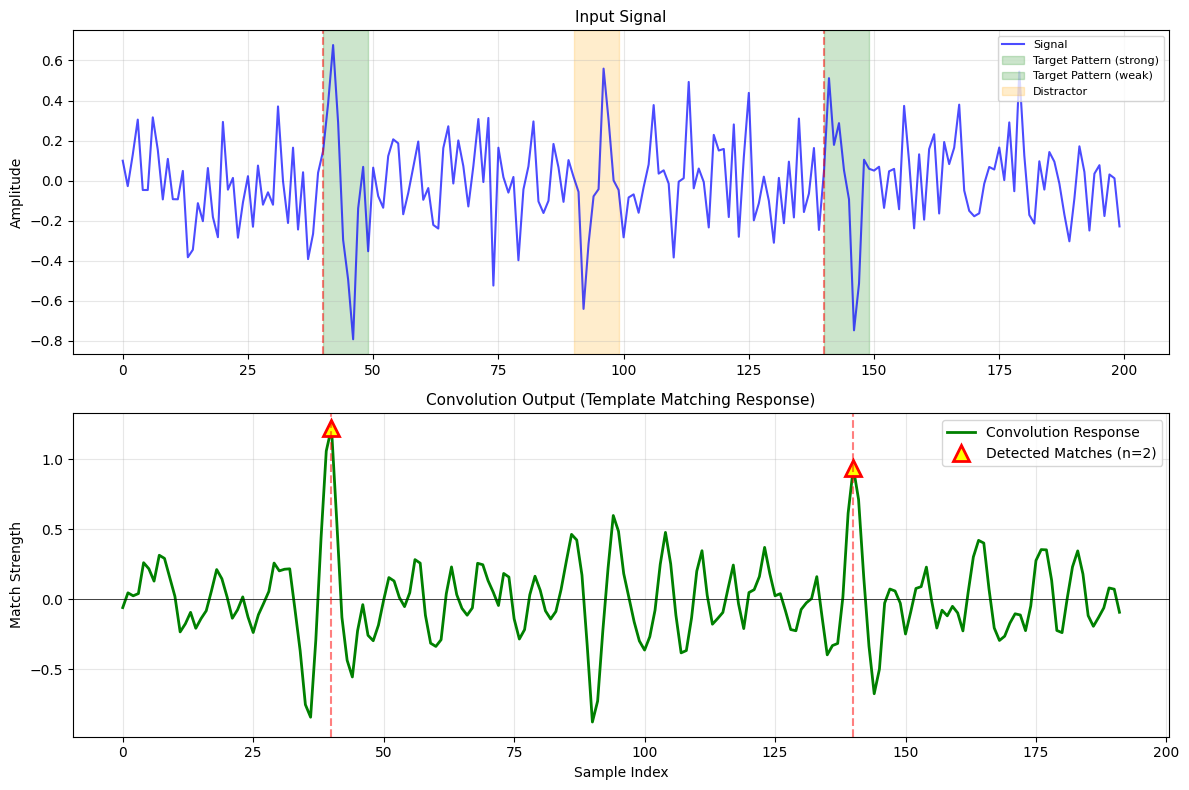


TEMPLATE MATCHING RESULTS
Template length: 9 samples
Signal length: 200 samples
Output length: 192 samples (valid convolution)

Detected peaks at positions: [ 40 140]
Peak values (match strength): ['1.225', '0.940']

Expected pattern positions: [40, 140]
Actual detected positions: [40, 140]

Correct detections: 2/2

Distractor region response (max): 0.599
Detection threshold: 0.8
Distractor correctly rejected: True

All peak responses:
  Position 40 (target, amp=1.0):  1.225
  Position 94 (distractor):       0.599
  Position 140 (target, amp=0.7): 0.940


In [44]:
# Apply convolution
conv1d = nn.Conv1d(1, 1, template_length, bias=False)
conv1d.weight.data = torch.tensor(template_normalized).view(1, 1, template_length).float()

signal_tensor = torch.from_numpy(signal).view(1, 1, -1).float()
with torch.no_grad():
    response = conv1d(signal_tensor).numpy().squeeze()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t, signal, 'b-', alpha=0.7, label='Signal')
axes[0].axvspan(40, 40+template_length, alpha=0.2, color='green', label='Target Pattern (strong)')
axes[0].axvspan(140, 140+template_length, alpha=0.2, color='green', label='Target Pattern (weak)')
axes[0].axvspan(90, 90+len(distractor), alpha=0.2, color='orange', label='Distractor')
axes[0].set_title('Input Signal', fontsize=11)
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Convolution response
response_t = t[:len(response)]
axes[1].plot(response_t, response, 'g-', linewidth=2, label='Convolution Response')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Find peaks with HIGHER threshold to reject distractor
peaks, properties = find_peaks(response, height=0.8, distance=template_length//2)

# Use TRIANGLE marker (▲) for detected peaks - indicates "peak/match"
axes[1].plot(response_t[peaks], response[peaks], 'r^', markersize=12, 
             markeredgewidth=2, markerfacecolor='yellow', 
             markeredgecolor='red', label=f'Detected Matches (n={len(peaks)})')

# Add vertical lines to show alignment
for peak in peaks:
    axes[1].axvline(x=response_t[peak], color='r', linestyle='--', alpha=0.5)
    axes[0].axvline(x=response_t[peak], color='r', linestyle='--', alpha=0.5)

axes[1].set_title('Convolution Output (Template Matching Response)', fontsize=11)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Match Strength')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
print(f"\n{'='*60}")
print("TEMPLATE MATCHING RESULTS")
print(f"{'='*60}")
print(f"Template length: {template_length} samples")
print(f"Signal length: {signal_length} samples")
print(f"Output length: {len(response)} samples (valid convolution)")

print(f"\nDetected peaks at positions: {response_t[peaks].astype(int)}")
print(f"Peak values (match strength): {[f'{v:.3f}' for v in response[peaks]]}")

expected_positions = [40, 140]
print(f"\nExpected pattern positions: {expected_positions}")
print(f"Actual detected positions: {list(response_t[peaks].astype(int))}")

# Check detection accuracy
detected_positions = list(response_t[peaks].astype(int))
correct_detections = sum(1 for exp in expected_positions 
                        if any(abs(d - exp) < 5 for d in detected_positions))
print(f"\nCorrect detections: {correct_detections}/{len(expected_positions)}")

# Check distractor rejection
distractor_center = 94
distractor_response = response[distractor_center - 5:distractor_center + 5]
print(f"\nDistractor region response (max): {np.max(distractor_response):.3f}")
print(f"Detection threshold: 0.8")
print(f"Distractor correctly rejected: {np.max(distractor_response) < 0.8}")

# Show all responses for comparison
print(f"\nAll peak responses:")
print(f"  Position 40 (target, amp=1.0):  {response[40]:.3f}")
print(f"  Position 94 (distractor):       {response[distractor_center]:.3f}")
print(f"  Position 140 (target, amp=0.7): {response[140]:.3f}")


### 5.4 Why This Works: The Mathematics

The convolution output at position $i$ computes the **normalized cross-correlation** between the template and the signal window starting at $i$:

$$\text{Response}[i] = \sum_{j} \text{Signal}[i+j] \times \text{Template}[j]$$

- **High positive value**: Signal matches template shape
- **Near zero**: No correlation (random noise)
- **Negative value**: Signal is opposite of template

This is essentially computing the **cosine similarity** between the template and local signal patches.

### 5.5 Key Insights

| Observation | Explanation |
|-------------|-------------|
| **Two clear peaks** | Template detected at both insertion points |
| **Peak heights differ** | 0.7 amplitude pattern produces weaker response than 1.0 |
| **Distractor rejected** | Flat shape doesn't match triangular template |
| **Peak width** | Related to template length; broader templates = broader peaks |

### 5.6 Real-World Connection: From 1D to 2D

This same principle extends directly to 2D CNNs for images:

| 1D (This Example) | 2D (Next Chapter) |
|-------------------|-------------------|
| Detect triangular pulse in signal | Detect edges, corners in images |
| Template: 1D array of length $k$ | Template: 2D kernel of size $k \times k$ |
| Output: 1D response curve | Output: 2D feature map (activation map) |
| Peaks = pattern locations | Bright spots = pattern locations |

> **Preview**: In the next chapter, instead of detecting 1D patterns like triangles, we'll detect 2D patterns like vertical edges, horizontal edges, and textures in images using `Conv2d`.

---

### Exercise: Design Your Own Detector

Modify the template to detect different patterns:
- **Square wave** (detect on/off transitions)
- **Gaussian pulse** (detect smooth bumps)
- **Derivative operator** (detect sudden changes)

Observe how the convolution response changes with each template shape.

## 6. Separating Mixed Signals with Multi-Output Convolution

Real-world signals often contain **overlapping frequency components**. A single convolution cannot separate them, but multiple output channels can act as **frequency-selective filters**.

### 6.1 Creating a Mixed Signal

We'll generate a signal containing:
- A **low-frequency sine wave** (baseline drift, 2 Hz)
- **High-frequency sawtooth pulses** (events, 20 Hz) appearing at specific times

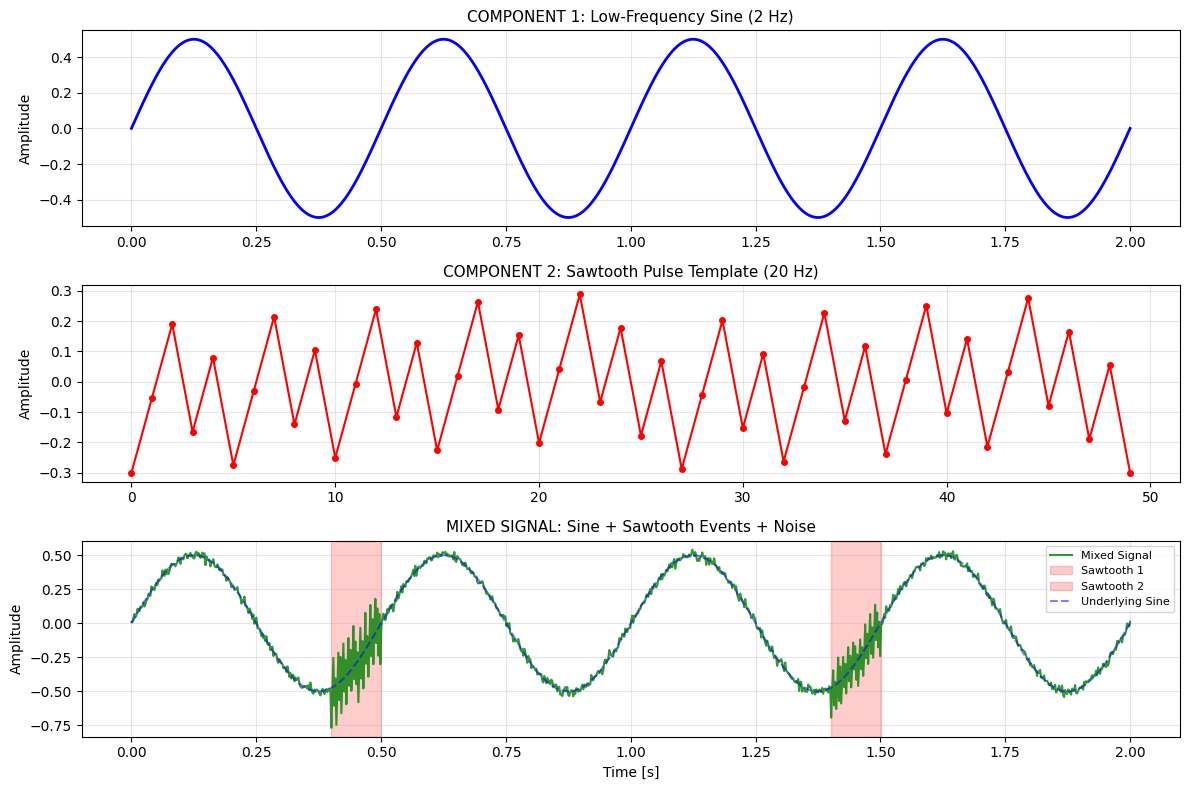

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import signal

np.random.seed(42)

# Time vector
t = np.linspace(0, 2, 1000)
signal_length = len(t)

# Component 1: Low-frequency sine (baseline)
sine_component = 0.5 * np.sin(2 * np.pi * 2 * t)

# Component 2: Sawtooth pulses (high-frequency events)
sawtooth_template = 0.3 * signal.sawtooth(2 * np.pi * 20 * np.linspace(0, 1, 50))
template_length = len(sawtooth_template)

# Create signal with sawtooth at positions 200 and 700
mixed_signal = sine_component.copy()
mixed_signal[200:200+template_length] += sawtooth_template
mixed_signal[700:700+template_length] += sawtooth_template * 0.7  # Smaller amplitude

# Add small noise
mixed_signal += np.random.normal(0, 0.02, signal_length)

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t, sine_component, 'b-', linewidth=2)
axes[0].set_title('COMPONENT 1: Low-Frequency Sine (2 Hz)', fontsize=11)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(template_length), sawtooth_template, 'r-o', markersize=4)
axes[1].set_title('COMPONENT 2: Sawtooth Pulse Template (20 Hz)', fontsize=11)
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, mixed_signal, 'g-', alpha=0.8, label='Mixed Signal')
axes[2].axvspan(t[200], t[200+template_length], alpha=0.2, color='red', label='Sawtooth 1')
axes[2].axvspan(t[700], t[700+template_length], alpha=0.2, color='red', label='Sawtooth 2')
axes[2].plot(t, sine_component, 'b--', alpha=0.5, label='Underlying Sine')
axes[2].set_title('MIXED SIGNAL: Sine + Sawtooth Events + Noise', fontsize=11)
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Amplitude')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Designing Two Selective Filters

In [51]:
# Filter 0: Large kernel moving average → extracts LOW frequencies (sine)
sine_kernel_size = 51
sine_kernel = np.ones(sine_kernel_size) / sine_kernel_size

# Filter 1: Matched filter for sawtooth → extracts HIGH frequencies (events)
# Use the sawtooth template itself as kernel
sawtooth_kernel = sawtooth_template - np.mean(sawtooth_template)
sawtooth_kernel = sawtooth_kernel / np.linalg.norm(sawtooth_kernel)

# Pad kernels to same length for Conv1d
max_length = max(len(sine_kernel), len(sawtooth_kernel))
sine_padded = np.zeros(max_length)
sine_padded[:len(sine_kernel)] = sine_kernel

sawtooth_padded = np.zeros(max_length)
start_idx = (max_length - len(sawtooth_kernel)) // 2
sawtooth_padded[start_idx:start_idx+len(sawtooth_kernel)] = sawtooth_kernel

# Stack: shape (2, 1, max_length)
weights = np.stack([sine_padded, sawtooth_padded])

# Create Conv1d: 1 input → 2 output channels
conv_sep = nn.Conv1d(in_channels=1, out_channels=2, kernel_size=max_length, bias=False)
conv_sep.weight.data = torch.tensor(weights).float().view(2, 1, max_length)

print(f"Filter 0 (Sine extractor): Moving average, size {sine_kernel_size}")
print(f"Filter 1 (Sawtooth detector): Template matching, size {len(sawtooth_kernel)}")
print(f"\nConv1d weights shape: {conv_sep.weight.shape}")

Filter 0 (Sine extractor): Moving average, size 51
Filter 1 (Sawtooth detector): Template matching, size 50

Conv1d weights shape: torch.Size([2, 1, 51])


### 6.3 Applying and Visualizing Separation

In [52]:
# Apply convolution
signal_tensor = torch.from_numpy(mixed_signal).view(1, 1, -1).float()
with torch.no_grad():
    output = conv_sep(signal_tensor)

# Extract channels
response_sine = output[0, 0, :].numpy()   # Channel 0: Low-pass (sine)
response_sawtooth = output[0, 1, :].numpy()  # Channel 1: Matched filter (sawtooth)

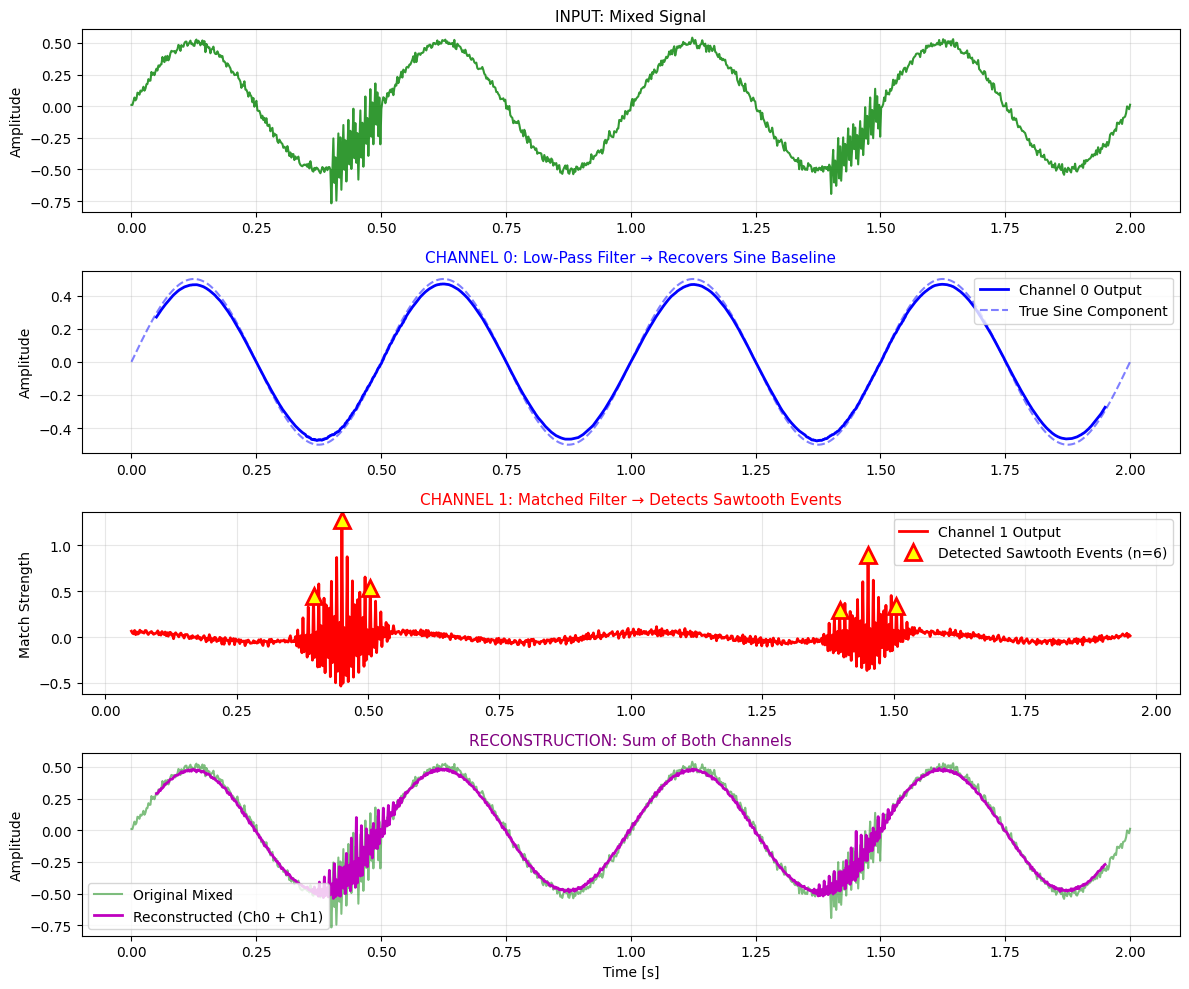


FREQUENCY SEPARATION RESULTS

Channel 0 (Low-Pass Filter):
  Recovers sine baseline with smoothing
  Suppresses high-frequency sawtooth components

Channel 1 (Matched Filter):
  Detected peaks at times: ['0.19', '0.21', '0.24', '0.69', '0.71', '0.74']s
  Expected: ~0.40s and ~1.40s
  Peak strengths: ['0.45', '1.27', '0.53', '0.30', '0.90', '0.34']

Key Insight:
  Each channel specializes in one frequency band
  → This is the foundation of CNN feature extraction!


In [53]:
# Adjust time axis (valid convolution shortens signal)# Calculate offsets for valid convolution
offset = max_length // 2
t_out_centered = t[offset:offset+len(response_sine)]

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

# Input
axes[0].plot(t, mixed_signal, 'g-', alpha=0.8)
axes[0].set_title('INPUT: Mixed Signal', fontsize=11)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Channel 0: Sine extraction (WITH offset correction)
axes[1].plot(t_out_centered, response_sine, 'b-', linewidth=2, label='Channel 0 Output')
axes[1].plot(t, sine_component, 'b--', alpha=0.5, label='True Sine Component')
axes[1].set_title('CHANNEL 0: Low-Pass Filter → Recovers Sine Baseline', fontsize=11, color='blue')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Channel 1: Sawtooth detection (WITH offset correction)
axes[2].plot(t_out_centered, response_sawtooth, 'r-', linewidth=2, label='Channel 1 Output')
peaks, _ = find_peaks(response_sawtooth, height=0.3, distance=template_length//2)
axes[2].plot(t_out_centered[peaks], response_sawtooth[peaks], 'r^', markersize=12,
             markerfacecolor='yellow', markeredgecolor='red', markeredgewidth=2,
             label=f'Detected Sawtooth Events (n={len(peaks)})')
axes[2].set_title('CHANNEL 1: Matched Filter → Detects Sawtooth Events', fontsize=11, color='red')
axes[2].set_ylabel('Match Strength')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Reconstruction (aligned with centered time)
axes[3].plot(t, mixed_signal, 'g-', alpha=0.5, label='Original Mixed')
reconstructed = response_sine + response_sawtooth * 0.3
axes[3].plot(t_out_centered, reconstructed, 'm-', linewidth=2, label='Reconstructed (Ch0 + Ch1)')
axes[3].set_title('RECONSTRUCTION: Sum of Both Channels', fontsize=11, color='purple')
axes[3].set_xlabel('Time [s]')
axes[3].set_ylabel('Amplitude')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
print(f"\n{'='*60}")
print("FREQUENCY SEPARATION RESULTS")
print(f"{'='*60}")
print(f"\nChannel 0 (Low-Pass Filter):")
print(f"  Recovers sine baseline with smoothing")
print(f"  Suppresses high-frequency sawtooth components")

print(f"\nChannel 1 (Matched Filter):")
print(f"  Detected peaks at times: {[f'{t:.2f}' for t in t_out[peaks]]}s")
print(f"  Expected: ~{t[200]:.2f}s and ~{t[700]:.2f}s")
print(f"  Peak strengths: {[f'{v:.2f}' for v in response_sawtooth[peaks]]}")

print(f"\nKey Insight:")
print(f"  Each channel specializes in one frequency band")
print(f"  → This is the foundation of CNN feature extraction!")



> **Note on Filter Design**
>
> In this educational example, we hand-designed the filters using prior knowledge of the signal components (moving average for sine, template matching for sawtooth). 
>
> In real-world scenarios where components are unknown, we rely on:
> - **Learned filters in CNNs**: Network discovers optimal filters through backpropagation
> - **Blind source separation (BSS)**: ICA, NMF, or autoencoders separate mixed signals without templates
> - **Adaptive filtering**: Algorithms like LMS/RLS adjust filters dynamically
>
> **Further Reading**: Blind Deconvolution, Independent Component Analysis (ICA), and ARIMA models for time series decomposition.

---

### 6.4 Summary: Filter Banks and Feature Channels

| Filter | Kernel Type | Detects | Output |
|--------|-------------|---------|--------|
| **Channel 0** | Large moving average (low-pass) | Slow variations | Baseline sine |
| **Channel 1** | Template matching (band-pass) | Sharp edges | Sawtooth events |

**Connection to Deep Learning:**
- Hand-designed filters → **Classical signal processing**
- Learned filters → **Deep CNNs** (next section)
- Multiple channels → **Feature maps** (each detects different patterns)

---

This version:
- Uses familiar sawtooth from your uploaded code
- Demonstrates clear frequency separation
- Maintains pedagogical progression (single → multi-output)
- Prepares students for learned filters in Section 7


---

## 7. Building a 1D CNN Classifier

Let's build a complete 1D CNN for classifying different types of signals.

### 7.1 Architecture


In [54]:

class SignalClassifier(nn.Module):
    def __init__(self, input_channels=1, num_classes=3):
        super(SignalClassifier, self).__init__()
        
        # Layer 1: Extract low-level features (edges, basic shapes)
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        
        # Layer 2: Extract higher-level patterns
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        
        # Layer 3: Deep features
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.AdaptiveAvgPool1d(1)  # Global average pooling
        
        # Classifier
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Feature extraction
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        
        # Flatten and classify
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Create model
model = SignalClassifier(input_channels=1, num_classes=3)
print(model)

# Test with dummy input
test_input = torch.randn(4, 1, 1000)  # Batch of 4 signals
output = model(test_input)
print(f"\nInput shape: {test_input.shape}")
print(f"Output shape: {output.shape}")

SignalClassifier(
  (conv1): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Input shape: torch.Size([4, 1, 1000])
Output shape: torch.Size([4, 3])


### 7.2 Training Loop Structure

In [55]:
import torch.optim as optim

# Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training step (simplified)
def train_step(model, data, labels):
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    return loss.item()

### 7.3 Application: Learn the Moving Average Kernel
Task: Learn the kernel weights through training instead of hand-designing.

In [79]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Target: moving average smoothing
def moving_average(x, kernel_size=3):
    kernel = np.ones(kernel_size) / kernel_size
    result = np.convolve(x, kernel, mode='valid')
    return result

# Generate data: random signals → smoothed versions
np.random.seed(42)
n_samples = 500
signal_length = 30

X = []
y = []

for _ in range(n_samples):
    # Random signal
    sig = np.random.randn(signal_length)
    # Target: smoothed version
    smoothed = moving_average(sig)
    
    X.append(sig)
    y.append(smoothed)


X = torch.tensor(X).float().view(n_samples, 1, signal_length)
print(X.shape)
y = torch.tensor(y).float().view(n_samples, 1, signal_length - 2)  # valid conv reduces length

# Simple model: single conv layer
class LearnableSmoothing(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(1, 1, kernel_size=3, bias=False)
        
    def forward(self, x):
        return self.conv(x)

model = LearnableSmoothing()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
print("Initial kernel:", model.conv.weight.data.squeeze().numpy())
print("Target kernel: [0.333, 0.333, 0.333]")

for epoch in range(100):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
        print(f"  Learned kernel: {model.conv.weight.data.squeeze().detach().numpy()}")

print(f"\nFinal learned kernel: {model.conv.weight.data.squeeze().detach().numpy()}")
print(f"Target kernel:        [0.333, 0.333, 0.333]")

torch.Size([500, 1, 30])
Initial kernel: [ 0.4156338  -0.24659362  0.3497005 ]
Target kernel: [0.333, 0.333, 0.333]
Epoch 0, Loss: 0.346503
  Learned kernel: [ 0.4056338  -0.23659362  0.33970052]
Epoch 20, Loss: 0.149662
  Learned kernel: [ 0.30775172 -0.04245146  0.32407022]
Epoch 40, Loss: 0.048288
  Learned kernel: [0.33728126 0.12145492 0.33068085]
Epoch 60, Loss: 0.010396
  Learned kernel: [0.33221686 0.23613878 0.33281395]
Epoch 80, Loss: 0.001246
  Learned kernel: [0.33197954 0.3003356  0.33280262]

Final learned kernel: [0.33355832 0.32660776 0.33330235]
Target kernel:        [0.333, 0.333, 0.333]



---

## 8. Application: ECG Heartbeat Detection (Further Reading)

Let's apply 1D CNN concepts to a more realistic problem: detecting heartbeats in ECG data.

### 8.1 Understanding ECG Signals

An ECG (electrocardiogram) measures electrical activity of the heart. Key features include:
- **P wave:** Atrial depolarization
- **QRS complex:** Ventricular depolarization (strongest signal)
- **T wave:** Ventricular repolarization

### 8.2 Simulating ECG Data

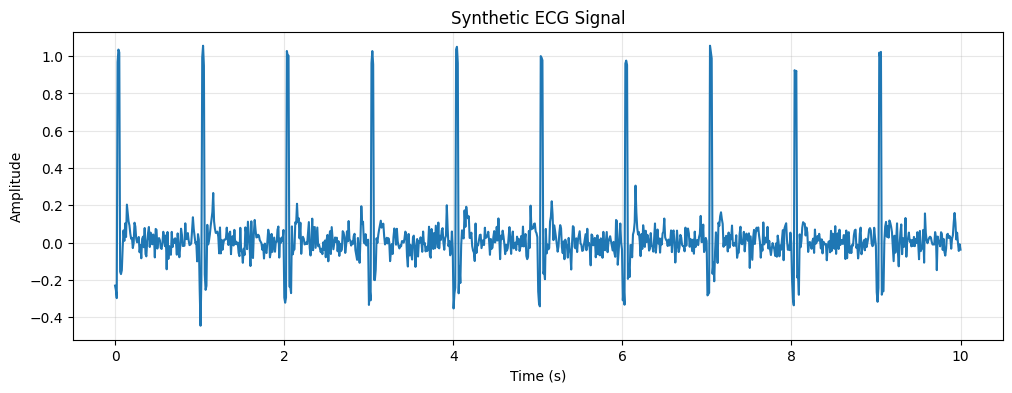

In [56]:

def generate_ecg_signal(length=1000, heart_rate=60, noise_level=0.05):
    """
    Generate synthetic ECG-like signal
    """
    t = np.linspace(0, 10, length)
    beat_interval = 60 / heart_rate  # seconds per beat
    num_beats = int(10 / beat_interval)
    
    signal = np.zeros(length)
    for i in range(num_beats):
        beat_time = i * beat_interval
        beat_idx = int(beat_time / 10 * length)
        
        # Create QRS complex (simplified)
        if beat_idx < length - 20:
            # P wave
            signal[beat_idx-10:beat_idx-5] += 0.1 * np.sin(np.linspace(0, np.pi, 5))
            # QRS complex
            signal[beat_idx:beat_idx+3] += -0.3  # Q
            signal[beat_idx+3:beat_idx+6] += 1.0  # R (peak)
            signal[beat_idx+6:beat_idx+9] += -0.2  # S
            # T wave
            signal[beat_idx+12:beat_idx+20] += 0.15 * np.sin(np.linspace(0, np.pi, 8))
    
    # Add noise
    signal += np.random.normal(0, noise_level, length)
    return t, signal

# Generate signal
t, ecg = generate_ecg_signal()

plt.figure(figsize=(12, 4))
plt.plot(t, ecg)
plt.title('Synthetic ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.show()

### 8.3 Detecting R-peaks with Convolution

We can design a kernel that responds strongly to QRS complexes:

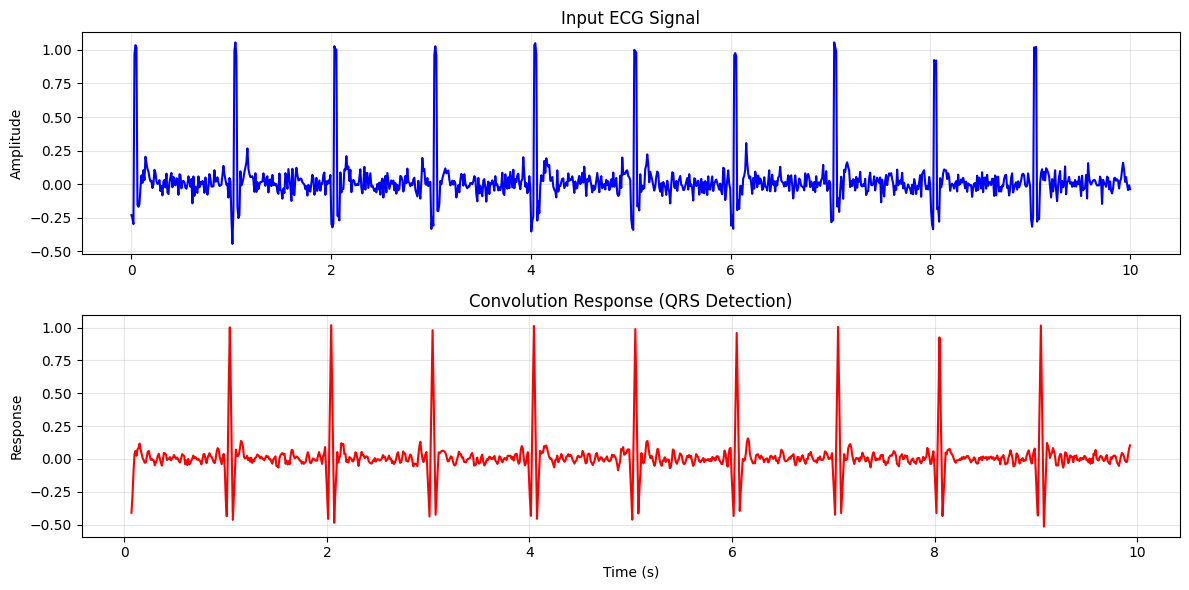

Detected 9 heartbeats


In [57]:

# Create a matched filter kernel (template matching)
template_length = 15
template = np.zeros(template_length)
template[3:6] = -0.3   # Q
template[6:9] = 1.0    # R
template[9:12] = -0.2  # S

# Normalize template
template = template / np.sum(template**2)

# Apply convolution
conv1d = nn.Conv1d(1, 1, template_length, bias=False)
conv1d.weight.data = torch.tensor(template).view(1, 1, template_length).float()

ecg_tensor = torch.from_numpy(ecg).view(1, 1, -1).float()
response = conv1d(ecg_tensor).detach().numpy().squeeze()

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t, ecg, 'b', label='ECG Signal')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Input ECG Signal')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[template_length//2:template_length//2+len(response)], 
             response, 'r', label='Filter Response')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Response')
axes[1].set_title('Convolution Response (QRS Detection)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find peaks in response (detected heartbeats)
from scipy.signal import find_peaks
peaks, _ = find_peaks(response, height=0.5, distance=50)
print(f"Detected {len(peaks)} heartbeats")


---

## 9. Multiple Channels and Filters (Further Reading)

Real-world applications often use multiple input channels and learn multiple features simultaneously.

### 9.1 Multi-Channel Input

Consider a traffic monitoring system with multiple sensors:

| Sensor        | Measures                               | Unit          | Relationship                         |
| ------------- | -------------------------------------- | ------------- | ------------------------------------ |
| **Speed**     | How fast vehicles are moving           | mph or km/h   | Inverse relationship with congestion |
| **Volume**    | How many vehicles pass a point         | vehicles/hour | Increases with traffic               |
| **Occupancy** | Percentage of road covered by vehicles | % (0-100)     | Direct measure of congestion         |


In [58]:
import numpy as np
import torch
# Simulate traffic data: (batch=1, sensors=3, time_steps=100)
# Channel 0: Speed sensors
# Channel 1: Volume sensors  
# Channel 2: Occupancy sensors

np.random.seed(42)
time_steps = 100
num_sensors = 3

# Generate correlated traffic data
t = np.arange(time_steps)
speed = 60 + 10 * np.sin(t/10) + np.random.normal(0, 2, time_steps)
volume = 100 - 1.5 * (speed - 60) + np.random.normal(0, 5, time_steps)
occupancy = volume / 200 + np.random.normal(0, 0.02, time_steps)

traffic_data = np.stack([speed, volume, occupancy])
traffic_tensor = torch.from_numpy(traffic_data).float().view(1, 3, time_steps)

print(f"Data shape: {traffic_data.shape}")
print(f"Tensor shape: {traffic_tensor.shape}")
# Output: torch.Size([1, 3, 100])

Data shape: (3, 100)
Tensor shape: torch.Size([1, 3, 100])


In [59]:
traffic_data[:,:4], traffic_tensor[:,:,:4]

(array([[60.99342831, 60.72180556, 63.28207038, 66.00126178],
        [91.43300383, 96.81406504, 93.36332184, 86.98672098],
        [ 0.46432077,  0.49528602,  0.48847763,  0.45600965]]),
 tensor([[[60.9934, 60.7218, 63.2821, 66.0013],
          [91.4330, 96.8141, 93.3633, 86.9867],
          [ 0.4643,  0.4953,  0.4885,  0.4560]]]))

### 9.2 Multi-Output Convolution


In [60]:
# Define layer: 3 input channels -> 5 output channels (filters)
conv_multi = nn.Conv1d(in_channels=3, out_channels=5, kernel_size=5, bias=True)

# Apply convolution
output = conv_multi(traffic_tensor)
print(f"Output shape: {output.shape}")
# Output: torch.Size([1, 5, 96])  (100 - 5 + 1 = 96)

# Each of the 5 output channels learns different patterns:
# - Channel 0: Might detect morning rush hour
# - Channel 1: Might detect accidents (sudden speed drop)
# - Channel 2: Might detect regular patterns
# etc.

Output shape: torch.Size([1, 5, 96])


### 9.3 Visualizing Learned Filters

Weights shape: torch.Size([5, 3, 5])


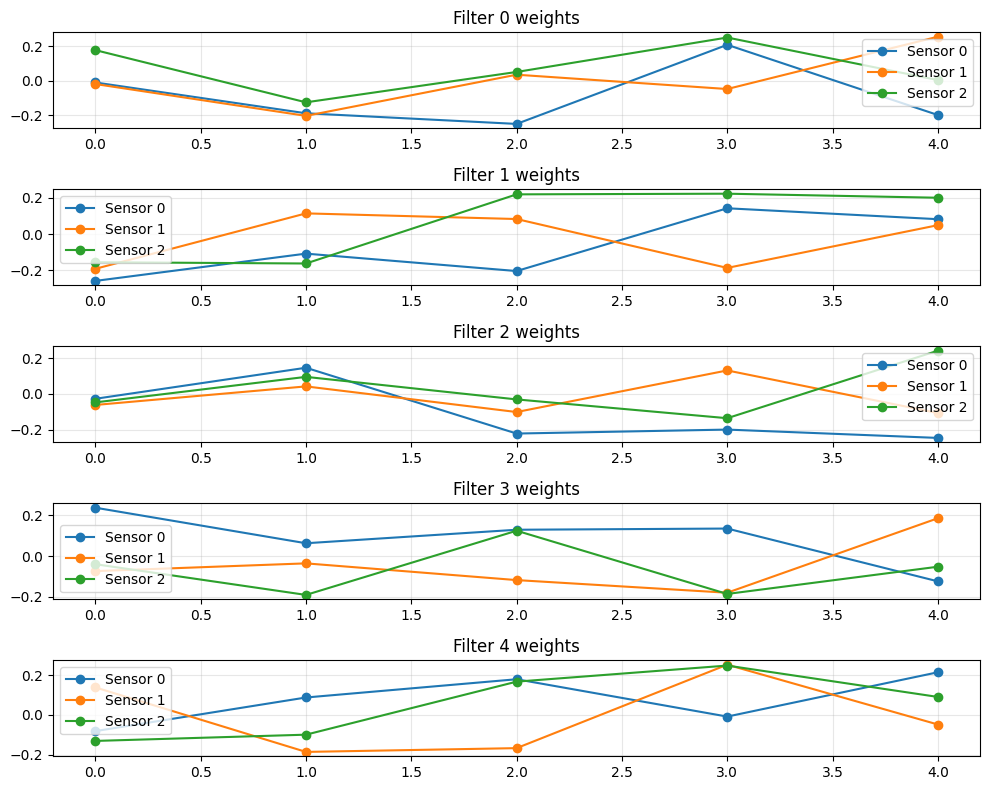

In [61]:
# Examine the learned weights
weights = conv_multi.weight.data  # Shape: (5, 3, 5)
print(f"Weights shape: {weights.shape}")

fig, axes = plt.subplots(5, 1, figsize=(10, 8))
for i in range(5):
    for j in range(3):
        axes[i].plot(weights[i, j].numpy(), 
                    label=f'Sensor {j}', marker='o')
    axes[i].set_title(f'Filter {i} weights')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 10. Connection to 2D CNNs

The concepts you've learned directly extend to 2D convolution for images:

| Concept | 1D (Time Series) | 2D (Images) |
|---------|-----------------|-------------|
| **Input shape** | `(B, C, L)` | `(B, C, H, W)` |
| **Kernel** | `(out_ch, in_ch, k)` | `(out_ch, in_ch, k, k)` |
| **Sliding direction** | Along length | Along height and width |
| **Detects** | Temporal patterns | Spatial patterns (edges, textures) |
| **Example** | Heartbeat in ECG | Edge in image |

The key insight is that **convolution is pattern matching**: in 1D we match temporal patterns, in 2D we match spatial patterns.

---

## 11. Summary

### Key Takeaways

1. **Convolution is local pattern detection**: The kernel slides across the input, computing similarity at each position.

2. **Kernel size controls receptive field**: Larger kernels capture more context but reduce output size and may blur details.

3. **Multiple channels enable rich representations**: Each filter learns to detect different features.

4. **1D CNNs are ideal for sequences**: Time series, audio, and sensor data benefit from translation-invariant pattern detection.

5. **Foundation for 2D**: Understanding 1D convolution makes 2D convolution intuitive—just add another dimension.

### Further Reading

- **PyTorch Documentation:** [`torch.nn.Conv1d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html)
- **Paper:** "Convolutional Neural Networks for Time Series Classification" (Ismail Fawaz et al., 2019)
- **Application:** WaveNet (DeepMind) uses dilated 1D convolutions for audio generation

---

## Exercises

1. **Kernel Design:** Design a kernel that detects sudden drops in a signal (anomaly detection). Test it on synthetic data.

2. **Stride Experiment:** Modify the smoothing example to use `stride=2`. How does this affect the output length and what does stride represent?

3. **Padding Comparison:** Compare `padding=0` (valid) vs `padding='same'` in PyTorch. When would you use each?

4. **Real Data:** Download a time series dataset (e.g., from UCR Time Series Archive) and build a 1D CNN classifier.

---

This chapter provides a solid foundation before students encounter 2D convolutions for image processing. The progression from manual calculations → SciPy → PyTorch → real applications mirrors how students should internalize the concepts.